# E-Commerce Behavior — Multi-Table EDA and What the Join Is Worth
> **236,000 rows across 5 tables that genuinely join** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/ecommerce-behavior)

| File | Rows | Columns |
| --- | ---: | ---: |
| `customers.csv` | 10,000 | 10 |
| `products.csv` | 1,000 | 11 |
| `transactions.csv` | 120,000 | 11 |
| `sessions.csv` | 80,000 | 10 |
| `reviews.csv` | 25,000 | 8 |

Section 1 re-prints these shapes straight from the files, so you never have to take a
markdown table's word for it.

## TL;DR

- **The join is real.** All five foreign-key edges resolve at 100%, and
  `transactions.unit_price` equals `products.price x (1 - discount_applied/100)` for
  every one of the 120,000 transaction rows.
- **The join pays.** Aggregating sessions and transactions onto the customer table
  lifts 5-fold churn ROC-AUC from 0.660 to 0.679 over a demographics-only baseline,
  and wins in all five folds.
- **Churned customers behave differently across tables**: fewer sessions, shorter
  sessions, more bounces, less completed spend. None of that is visible in
  `customers.csv` alone.
- **One trap to know about:** `lifetime_value` is assigned from the customer's
  segment, not summed from `transactions`. It correlates with realized completed
  spend at r = 0.56. Treat it as a segment proxy, not a derived total.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships
  with the dataset. Good for teaching, benchmarking and prototyping; not evidence
  about real shoppers.

## Contents

1. [Setup & data loading](#setup)
2. [Objective & evaluation plan](#objective)
3. [Does it actually join?](#join)
4. [Building a customer-360 table](#c360)
5. [Cross-table findings](#findings)
6. [What the join is worth](#worth)
7. [Single-table EDA on customers](#eda)
8. [Evaluation readiness](#evaluation)
9. [Key takeaways](#takeaways)

## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 11

DATA_DIR = "/kaggle/input/ecommerce-behavior"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "."

TABLES = ["customers", "products", "transactions", "sessions", "reviews"]
frames = {name: pd.read_csv(f"{DATA_DIR}/{name}.csv") for name in TABLES}

customers = frames["customers"]
products = frames["products"]
transactions = frames["transactions"]
sessions = frames["sessions"]
reviews = frames["reviews"]

# The single-table EDA in section 7 works on the customer table.
df = customers

print(f"{'file':<20} {'rows':>9} {'cols':>6}   memory")
print("-" * 52)
for name in TABLES:
    frame = frames[name]
    mem = frame.memory_usage(deep=True).sum() / 1e6
    print(f"{name + '.csv':<20} {len(frame):>9,} {frame.shape[1]:>6}   {mem:>6.1f} MB")
print("-" * 52)
print(f"{'total':<20} {sum(len(f) for f in frames.values()):>9,}")

file                      rows   cols   memory
----------------------------------------------------
customers.csv           10,000     10      1.1 MB
products.csv             1,000     11      0.1 MB
transactions.csv       120,000     11     17.2 MB
sessions.csv            80,000     10     10.1 MB
reviews.csv             25,000      8      3.0 MB
----------------------------------------------------
total                  236,000


In [2]:
customers.head()

,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
0,C00000,2020-02-13,28,M,BR,Premium,0,1595.27,0,0
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,1160.61,1,0
2,C00002,2022-06-26,30,F,US,VIP,0,3093.32,1,1
3,C00003,2021-12-21,48,F,US,Premium,1,2131.08,1,0
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.39,0,1


## 2. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** predict `customers.is_churned`, and measure how much of the signal
only becomes available once the behavioural tables are joined on.

**Why that framing:** a churn model built from `customers.csv` alone is the honest
baseline for a single-table dataset. Everything this dataset claims to offer over a
single CSV should show up as a difference against that baseline, so section 6
measures exactly that rather than asserting it.

**Evaluation:** 5-fold stratified ROC-AUC. The label is imbalanced, so accuracy would
be dominated by the majority class; stratification keeps the churn rate stable across
folds.

In [3]:
TARGET_COL = "is_churned"
MODELING_TASK = "classification"
PRIMARY_METRIC = "ROC-AUC (5-fold stratified)"

churn_rate = customers[TARGET_COL].mean()

print("Objective framing")
print("-" * 60)
print(f"Rows available      : {len(customers):,} customers")
print(f"Candidate target    : {TARGET_COL}")
print(
    f"Positive class rate : {churn_rate:.2%} "
    f"({int(customers[TARGET_COL].sum()):,} churned)"
)
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(
    f"Joinable rows       : {len(sessions):,} sessions + "
    f"{len(transactions):,} transactions + {len(reviews):,} reviews"
)

Objective framing
------------------------------------------------------------
Rows available      : 10,000 customers
Candidate target    : is_churned
Positive class rate : 16.94% (1,694 churned)
Modeling task       : classification
Primary metric      : ROC-AUC (5-fold stratified)
Joinable rows       : 80,000 sessions + 120,000 transactions + 25,000 reviews


## 3. Does It Actually Join? <a id='join'></a>

The dataset description promises that the tables "join cleanly on `customer_id` and
`product_id`". That is the kind of claim a downloader should make the data prove, so
here it is checked rather than repeated: every foreign-key edge, in both directions,
plus the price identity that ties `transactions` to `products`.

In [4]:
EDGES = [
    ("transactions.customer_id", transactions["customer_id"], customers["customer_id"]),
    ("sessions.customer_id", sessions["customer_id"], customers["customer_id"]),
    ("reviews.customer_id", reviews["customer_id"], customers["customer_id"]),
    ("transactions.product_id", transactions["product_id"], products["product_id"]),
    ("reviews.product_id", reviews["product_id"], products["product_id"]),
]

print("Foreign key -> parent table         resolved     orphan rows")
print("-" * 62)
integrity = {}
for label, child, parent in EDGES:
    resolved = child.isin(parent).mean()
    orphans = int((~child.isin(parent)).sum())
    integrity[label] = resolved
    print(f"{label:<35} {resolved:>7.2%} {orphans:>15,}")

print()
print("Reverse coverage (parents with at least one child row)")
print("-" * 62)
coverage = {
    "customers with >=1 transaction": customers["customer_id"]
    .isin(transactions["customer_id"])
    .mean(),
    "customers with >=1 session": customers["customer_id"]
    .isin(sessions["customer_id"])
    .mean(),
    "customers with >=1 review": customers["customer_id"]
    .isin(reviews["customer_id"])
    .mean(),
    "products with >=1 transaction": products["product_id"]
    .isin(transactions["product_id"])
    .mean(),
    "products with >=1 review": products["product_id"]
    .isin(reviews["product_id"])
    .mean(),
}
for label, value in coverage.items():
    print(f"{label:<35} {value:>7.2%}")

Foreign key -> parent table         resolved     orphan rows
--------------------------------------------------------------
transactions.customer_id            100.00%               0
sessions.customer_id                100.00%               0
reviews.customer_id                 100.00%               0
transactions.product_id             100.00%               0
reviews.product_id                  100.00%               0

Reverse coverage (parents with at least one child row)
--------------------------------------------------------------
customers with >=1 transaction       99.41%
customers with >=1 session           98.24%
customers with >=1 review            91.74%
products with >=1 transaction       100.00%
products with >=1 review            100.00%


In [5]:
# The price chain: does transactions.unit_price agree with the product catalogue?
tx_prod = transactions.merge(
    products[["product_id", "category", "price"]], on="product_id"
)
expected_unit = (tx_prod["price"] * (1 - tx_prod["discount_applied"] / 100)).round(2)
matches = (tx_prod["unit_price"] - expected_unit).abs() < 0.02

print("unit_price == products.price x (1 - discount_applied/100)")
print(f"  holds for {matches.mean():.2%} of {len(tx_prod):,} joined transaction rows")
print(
    f"  correlation(unit_price, catalogue price) = "
    f"{tx_prod['unit_price'].corr(tx_prod['price']):.4f}"
)
print()
print("Modelling note: unit_price is fully derivable from the join, so it is a leak")
print(
    "for any task that predicts price or discount. Drop it there; keep it for revenue."
)

unit_price == products.price x (1 - discount_applied/100)
  holds for 100.00% of 120,000 joined transaction rows
  correlation(unit_price, catalogue price) = 0.9822

Modelling note: unit_price is fully derivable from the join, so it is a leak
for any task that predicts price or discount. Drop it there; keep it for revenue.


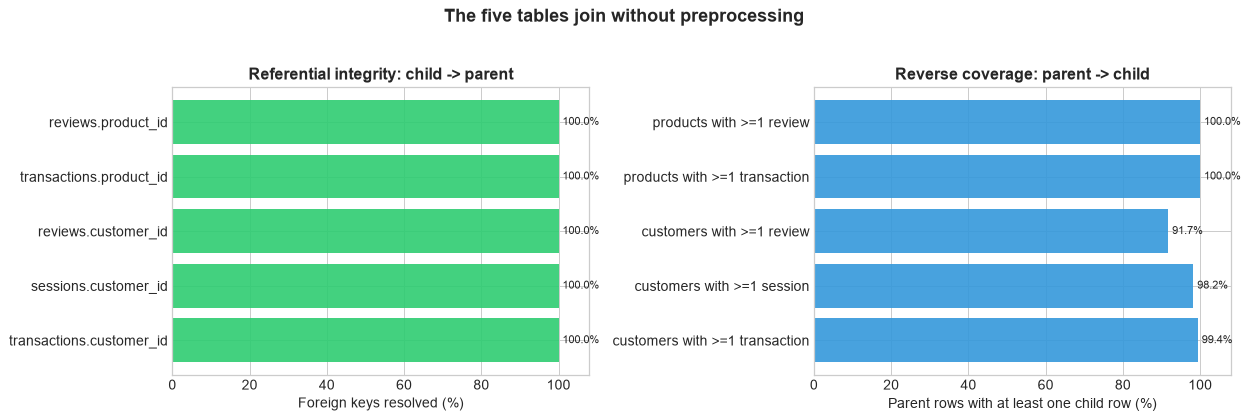

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

labels = list(integrity)
values = [integrity[k] * 100 for k in labels]
bars = ax1.barh(labels, values, color="#2ecc71", alpha=0.9)
ax1.set_xlim(0, 108)
ax1.set_xlabel("Foreign keys resolved (%)")
ax1.set_title("Referential integrity: child -> parent", fontweight="bold")
for bar, value in zip(bars, values):
    ax1.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )

cov_labels = list(coverage)
cov_values = [coverage[k] * 100 for k in cov_labels]
bars = ax2.barh(cov_labels, cov_values, color="#3498db", alpha=0.9)
ax2.set_xlim(0, 108)
ax2.set_xlabel("Parent rows with at least one child row (%)")
ax2.set_title("Reverse coverage: parent -> child", fontweight="bold")
for bar, value in zip(bars, cov_values):
    ax2.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )

plt.suptitle(
    "The five tables join without preprocessing", fontsize=14, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

## 4. Building a Customer-360 Table <a id='c360'></a>

One left join per child table turns 236,000 event rows into one row per customer. This
is the table the rest of the notebook models on, and it is the shape most real
relational feature pipelines end up in.

In [7]:
session_feats = sessions.groupby("customer_id").agg(
    sessions_n=("session_id", "size"),
    session_conv_rate=("converted", "mean"),
    session_bounce_rate=("bounced", "mean"),
    avg_session_seconds=("duration_seconds", "mean"),
    avg_pages_viewed=("pages_viewed", "mean"),
    cart_additions=("cart_additions", "sum"),
)

order_feats = transactions.groupby("customer_id").agg(
    orders_n=("transaction_id", "size"),
)

completed = transactions[transactions["status"] == "completed"]
spend_feats = completed.groupby("customer_id").agg(
    completed_spend=("total_amount", "sum"),
    completed_orders=("transaction_id", "size"),
    avg_order_value=("total_amount", "mean"),
)

review_feats = reviews.groupby("customer_id").agg(
    reviews_n=("review_id", "size"),
    avg_review_rating=("rating", "mean"),
)

c360 = customers.set_index("customer_id").join(
    [session_feats, order_feats, spend_feats, review_feats]
)

# A customer with no sessions has zero sessions, not an unknown number of them.
COUNT_COLS = [
    "sessions_n",
    "cart_additions",
    "orders_n",
    "completed_spend",
    "completed_orders",
    "reviews_n",
]
c360[COUNT_COLS] = c360[COUNT_COLS].fillna(0)

print(f"customer-360 table: {c360.shape[0]:,} rows x {c360.shape[1]} columns")
print(
    f"(from {len(customers):,} customers + "
    f"{len(sessions) + len(transactions) + len(reviews):,} event rows)"
)
print()
print("Columns still holding NaN (genuinely undefined, not zero):")
still_missing = c360.isna().sum()
print(still_missing[still_missing > 0].to_string())

customer-360 table: 10,000 rows x 21 columns
(from 10,000 customers + 225,000 event rows)

Columns still holding NaN (genuinely undefined, not zero):
session_conv_rate      176
session_bounce_rate    176
avg_session_seconds    176
avg_pages_viewed       176
avg_order_value        270
avg_review_rating      826


In [8]:
c360.head()

,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app,sessions_n,session_conv_rate,session_bounce_rate,avg_session_seconds,avg_pages_viewed,cart_additions,orders_n,completed_spend,completed_orders,avg_order_value,reviews_n,avg_review_rating
customer_id,,,,,,,,,,,,,,,,,,,,,
C00000,2020-02-13,28,M,BR,Premium,0,1595.27,0,0,8.0,0.125000,0.125000,696.875000,10.750000,5.0,25.0,706.65,18.0,39.258333,0.0,NaN
C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,1160.61,1,0,12.0,0.000000,0.083333,325.500000,6.833333,4.0,12.0,244.64,5.0,48.928000,1.0,2.0
C00002,2022-06-26,30,F,US,VIP,0,3093.32,1,1,29.0,0.103448,0.068966,439.896552,7.482759,31.0,29.0,1104.66,16.0,69.041250,2.0,2.5
C00003,2021-12-21,48,F,US,Premium,1,2131.08,1,0,17.0,0.117647,0.176471,284.588235,5.176471,20.0,26.0,695.06,15.0,46.337333,1.0,4.0
C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.39,0,1,1.0,0.000000,0.000000,216.000000,5.000000,0.0,4.0,148.32,2.0,74.160000,1.0,2.0


## 5. Cross-Table Findings <a id='findings'></a>

Three things that only exist once the tables are joined.

In [9]:
# Finding 1 - churn shows up in behaviour, not in demographics.
BEHAVIOUR = [
    "sessions_n",
    "avg_session_seconds",
    "session_conv_rate",
    "session_bounce_rate",
    "orders_n",
    "completed_spend",
]
gap = c360.groupby("is_churned")[BEHAVIOUR].mean()
gap.index = ["retained", "churned"]

print("Behavioural profile by churn label (means)")
print(gap.round(3).to_string())
print()
print("Relative difference, churned vs retained:")
for col in BEHAVIOUR:
    delta = gap.loc["churned", col] / gap.loc["retained", col] - 1
    print(f"  {col:<22} {delta:+7.1%}")

Behavioural profile by churn label (means)
          sessions_n  avg_session_seconds  session_conv_rate  session_bounce_rate  orders_n  completed_spend
retained       8.488              312.012              0.088                0.106    12.750          579.429
churned        5.606              235.060              0.065                0.134     8.322          372.203

Relative difference, churned vs retained:
  sessions_n              -34.0%
  avg_session_seconds     -24.7%
  session_conv_rate       -25.5%
  session_bounce_rate     +26.1%
  orders_n                -34.7%
  completed_spend         -35.8%


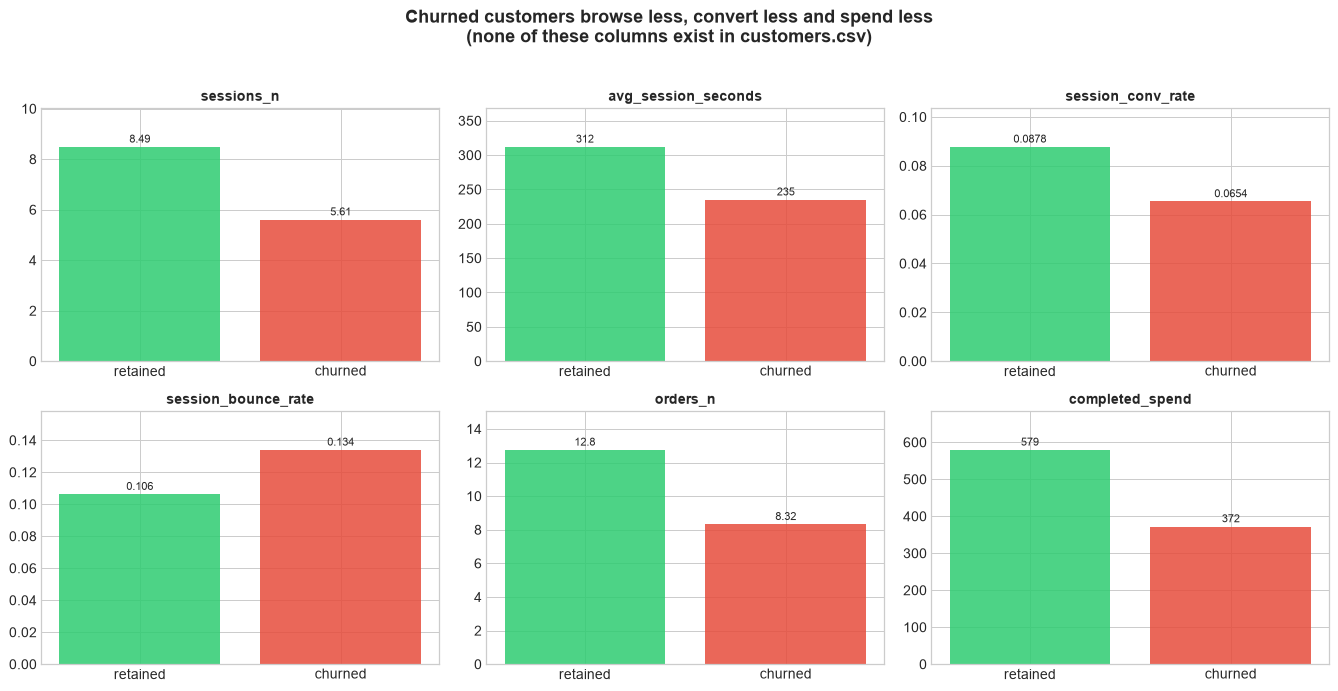

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, col in zip(axes.flatten(), BEHAVIOUR):
    vals = [gap.loc["retained", col], gap.loc["churned", col]]
    bars = ax.bar(
        ["retained", "churned"], vals, color=["#2ecc71", "#e74c3c"], alpha=0.85
    )
    ax.set_title(col, fontweight="bold", fontsize=11)
    top = max(vals)
    for bar, value in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + top * 0.02,
            f"{value:,.3g}",
            ha="center",
            fontsize=9,
        )
    ax.set_ylim(0, top * 1.18)

plt.suptitle(
    "Churned customers browse less, convert less and spend less\n"
    "(none of these columns exist in customers.csv)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

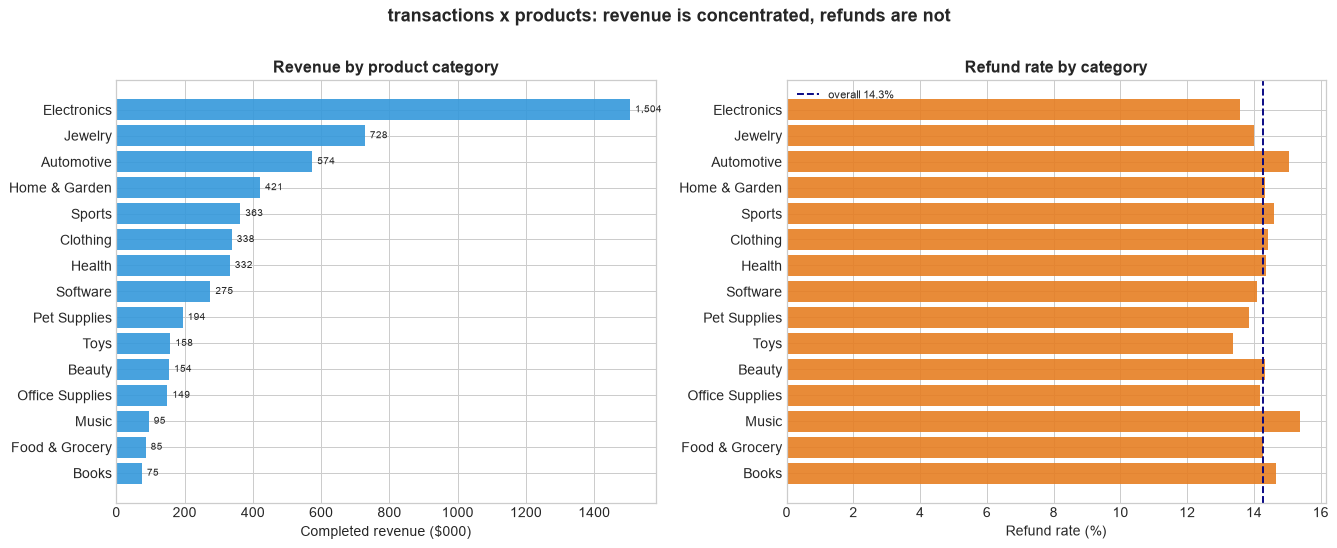

Electronics alone is 27.6% of completed revenue ($1,504,492 of $5,443,248).
Refund rate by category spans only 13.4% to 15.4% across 15 categories, so category is a strong revenue signal and a weak refund signal.


In [11]:
# Finding 2 - where the money is, once transactions are joined to the catalogue.
completed_joined = tx_prod[tx_prod["status"] == "completed"]
revenue = completed_joined.groupby("category")["total_amount"].sum().sort_values()
refund_rate = (
    tx_prod.assign(is_refund=tx_prod["status"].eq("refunded"))
    .groupby("category")["is_refund"]
    .mean()
    .reindex(revenue.index)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

bars = ax1.barh(revenue.index, revenue.values / 1000, color="#3498db", alpha=0.9)
ax1.set_xlabel("Completed revenue ($000)")
ax1.set_title("Revenue by product category", fontweight="bold")
for bar, value in zip(bars, revenue.values / 1000):
    ax1.text(
        value + revenue.max() / 1000 * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=8,
    )

ax2.barh(refund_rate.index, refund_rate.values * 100, color="#e67e22", alpha=0.9)
ax2.set_xlabel("Refund rate (%)")
ax2.set_title("Refund rate by category", fontweight="bold")
ax2.axvline(
    tx_prod["status"].eq("refunded").mean() * 100,
    color="navy",
    linestyle="--",
    label=f"overall {tx_prod['status'].eq('refunded').mean():.1%}",
)
ax2.legend(fontsize=9)

plt.suptitle(
    "transactions x products: revenue is concentrated, refunds are not",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

top = revenue.sort_values(ascending=False)
share = top.iloc[0] / top.sum()
print(
    f"{top.index[0]} alone is {share:.1%} of completed revenue "
    f"(${top.iloc[0]:,.0f} of ${top.sum():,.0f})."
)
print(
    f"Refund rate by category spans only "
    f"{refund_rate.min():.1%} to {refund_rate.max():.1%} across "
    f"{refund_rate.size} categories, so category is a strong revenue signal "
    f"and a weak refund signal."
)

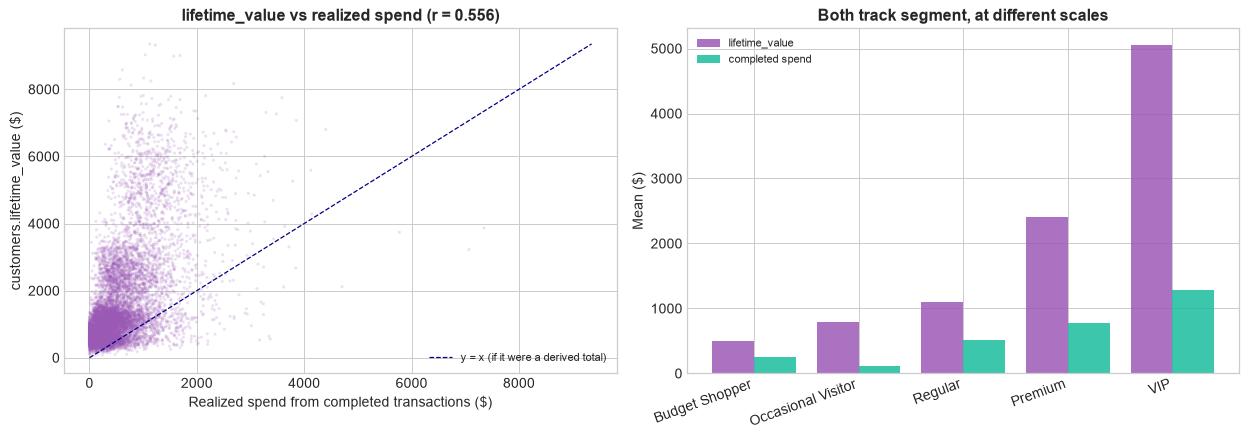

mean lifetime_value  : $1,544.61
mean completed spend : $544.32
correlation          : 0.556

lifetime_value is assigned from the customer segment, not summed from
transactions. Use it as a segment proxy; if you want a spend target,
build it from transactions.csv so you control the definition.


In [12]:
# Finding 3 - the lifetime_value trap.
r_ltv = c360["lifetime_value"].corr(c360["completed_spend"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(
    c360["completed_spend"],
    c360["lifetime_value"],
    s=6,
    alpha=0.18,
    color="#9b59b6",
    edgecolors="none",
)
ax1.set_xlabel("Realized spend from completed transactions ($)")
ax1.set_ylabel("customers.lifetime_value ($)")
ax1.set_title(f"lifetime_value vs realized spend (r = {r_ltv:.3f})", fontweight="bold")
limit = max(c360["completed_spend"].max(), c360["lifetime_value"].max())
ax1.plot(
    [0, limit],
    [0, limit],
    color="navy",
    linestyle="--",
    linewidth=1,
    label="y = x (if it were a derived total)",
)
ax1.legend(fontsize=9)

by_segment = c360.groupby("segment")[["lifetime_value", "completed_spend"]].mean()
by_segment = by_segment.sort_values("lifetime_value")
x = np.arange(len(by_segment))
ax2.bar(
    x - 0.2,
    by_segment["lifetime_value"],
    width=0.4,
    label="lifetime_value",
    color="#9b59b6",
    alpha=0.85,
)
ax2.bar(
    x + 0.2,
    by_segment["completed_spend"],
    width=0.4,
    label="completed spend",
    color="#1abc9c",
    alpha=0.85,
)
ax2.set_xticks(x)
ax2.set_xticklabels(by_segment.index, rotation=20, ha="right")
ax2.set_ylabel("Mean ($)")
ax2.set_title("Both track segment, at different scales", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"mean lifetime_value  : ${c360['lifetime_value'].mean():,.2f}")
print(f"mean completed spend : ${c360['completed_spend'].mean():,.2f}")
print(f"correlation          : {r_ltv:.3f}")
print()
print("lifetime_value is assigned from the customer segment, not summed from")
print("transactions. Use it as a segment proxy; if you want a spend target,")
print("build it from transactions.csv so you control the definition.")

## 6. What the Join Is Worth <a id='worth'></a>

The claim to test: joining the behavioural tables beats modelling `customers.csv` on
its own. Same model, same folds, same seed — only the feature set changes.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SINGLE_TABLE = ["age", "email_opt_in", "has_app", "lifetime_value"]
JOINED = SINGLE_TABLE + [
    "sessions_n",
    "session_conv_rate",
    "session_bounce_rate",
    "avg_session_seconds",
    "avg_pages_viewed",
    "cart_additions",
    "orders_n",
    "completed_spend",
    "reviews_n",
]

y = c360["is_churned"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_auc(columns):
    X = c360[columns]
    X = X.fillna(X.median())
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    return cross_val_score(model, X, y, cv=cv, scoring="roc_auc")


single_scores = cv_auc(SINGLE_TABLE)
joined_scores = cv_auc(JOINED)

print(f"{'fold':<6} {'customers.csv only':>20} {'+ joined behaviour':>20} {'delta':>9}")
print("-" * 58)
for i, (a, b) in enumerate(zip(single_scores, joined_scores), start=1):
    print(f"{i:<6} {a:>20.4f} {b:>20.4f} {b - a:>+9.4f}")
print("-" * 58)
print(
    f"{'mean':<6} {single_scores.mean():>20.4f} {joined_scores.mean():>20.4f} "
    f"{joined_scores.mean() - single_scores.mean():>+9.4f}"
)
print(f"{'std':<6} {single_scores.std():>20.4f} {joined_scores.std():>20.4f}")
print()
print(
    f"The joined feature set wins {int((joined_scores > single_scores).sum())} "
    f"of {len(joined_scores)} folds."
)

fold     customers.csv only   + joined behaviour     delta
----------------------------------------------------------
1                    0.6679               0.6921   +0.0242
2                    0.6476               0.6724   +0.0247
3                    0.6539               0.6835   +0.0296
4                    0.6759               0.6820   +0.0061
5                    0.6574               0.6643   +0.0070
----------------------------------------------------------
mean                 0.6605               0.6789   +0.0183
std                  0.0101               0.0096

The joined feature set wins 5 of 5 folds.


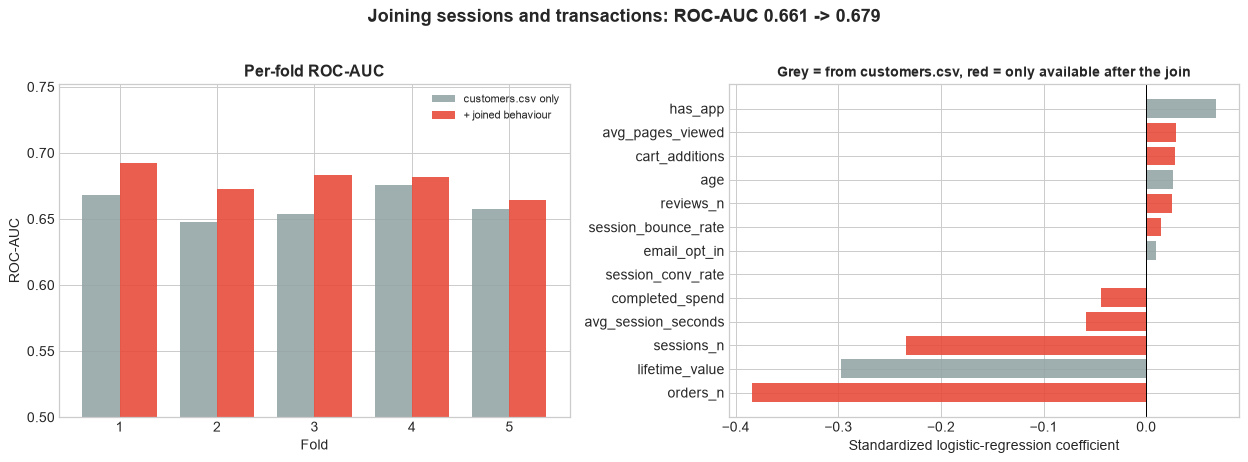

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

folds = np.arange(1, len(single_scores) + 1)
width = 0.38
ax1.bar(
    folds - width / 2,
    single_scores,
    width,
    label="customers.csv only",
    color="#95a5a6",
    alpha=0.9,
)
ax1.bar(
    folds + width / 2,
    joined_scores,
    width,
    label="+ joined behaviour",
    color="#e74c3c",
    alpha=0.9,
)
ax1.set_xticks(folds)
ax1.set_xlabel("Fold")
ax1.set_ylabel("ROC-AUC")
ax1.set_ylim(0.5, max(joined_scores) + 0.06)
ax1.axhline(0.5, color="black", linewidth=0.8, linestyle=":")
ax1.set_title("Per-fold ROC-AUC", fontweight="bold")
ax1.legend(fontsize=9)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
X_joined = c360[JOINED].fillna(c360[JOINED].median())
model.fit(X_joined, y)
weights = pd.Series(model[-1].coef_[0], index=JOINED).sort_values()
colors = ["#95a5a6" if name in SINGLE_TABLE else "#e74c3c" for name in weights.index]
ax2.barh(weights.index, weights.values, color=colors, alpha=0.9)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Standardized logistic-regression coefficient")
ax2.set_title(
    "Grey = from customers.csv, red = only available after the join",
    fontweight="bold",
    fontsize=11,
)

plt.suptitle(
    f"Joining sessions and transactions: ROC-AUC "
    f"{single_scores.mean():.3f} -> {joined_scores.mean():.3f}",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 7. Single-Table EDA on `customers` <a id='eda'></a>

The conventional pass over the customer table: missingness, distributions,
categoricals, correlations and the target itself.

In [15]:
print("Column Types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print()
df.describe().round(2)

Column Types:
str        5
int64      4
float64    1

Duplicate rows: 0
Total missing values: 0



,age,is_churned,lifetime_value,email_opt_in,has_app
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,35.33,0.17,1544.61,0.70,0.56
std,11.17,0.38,1426.69,0.46,0.50
min,18.00,0.00,71.21,0.00,0.00
25%,27.00,0.00,587.94,0.00,0.00
50%,35.00,0.00,1043.80,1.00,1.00
75%,43.00,0.00,1952.15,1.00,1.00
max,75.00,1.00,9353.25,1.00,1.00


In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"count": missing, "percent": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("percent", ascending=False)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    colors = [
        "#e74c3c" if p > 20 else "#f39c12" if p > 5 else "#2ecc71"
        for p in missing_df["percent"]
    ]
    bars = ax.barh(missing_df.index, missing_df["percent"], color=colors, alpha=0.85)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in customers.csv — every column is complete.")
    print("The joined table in section 4 is where missingness actually appears,")
    print("and it appears there for a reason: customers with no sessions at all.")

No missing values in customers.csv — every column is complete.
The joined table in section 4 is where missingness actually appears,
and it appears there for a reason: customers with no sessions at all.


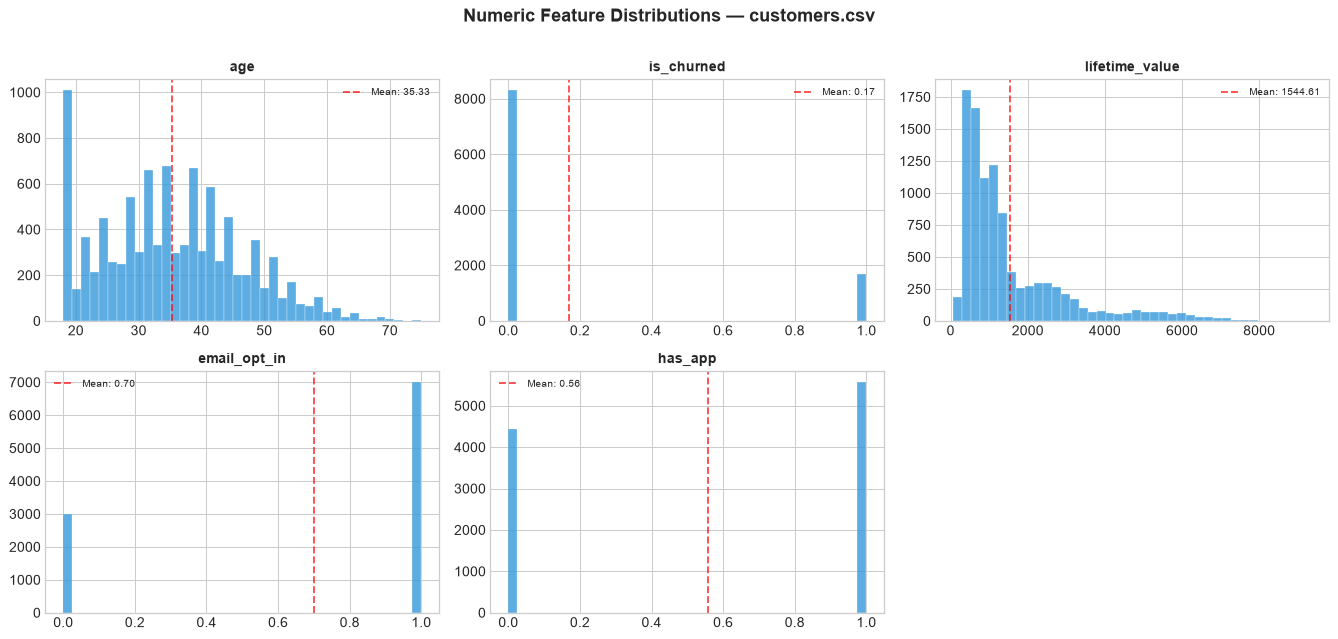

In [17]:
NUMERIC_COLS = ["age", "is_churned", "lifetime_value", "email_opt_in", "has_app"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    ax.hist(
        df[col].dropna(),
        bins=40,
        color="#3498db",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.3,
    )
    mean_val = df[col].mean()
    ax.axvline(
        mean_val, color="red", linestyle="--", alpha=0.7, label=f"Mean: {mean_val:.2f}"
    )
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Numeric Feature Distributions — customers.csv",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

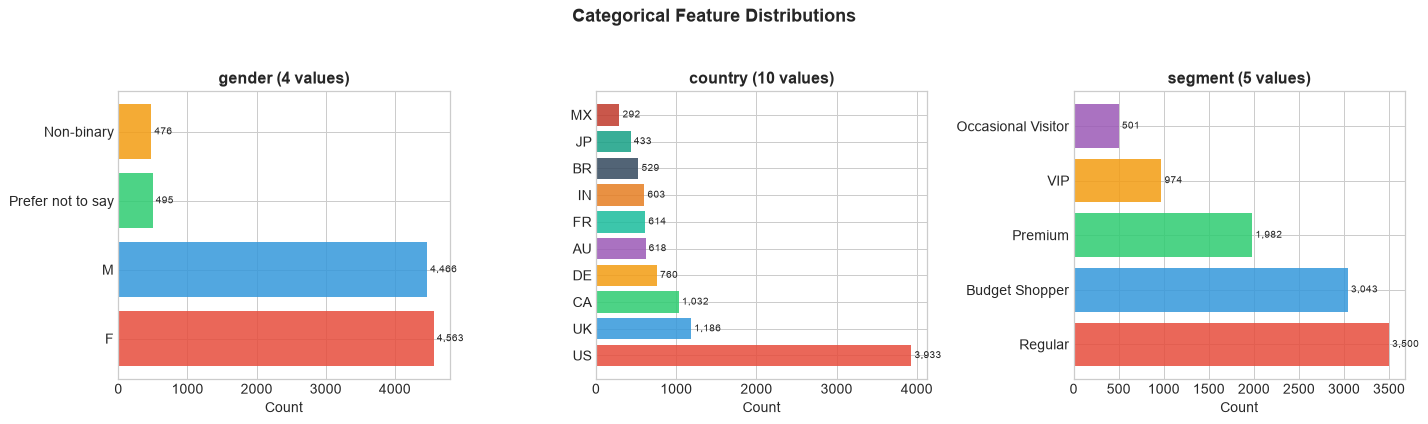

In [18]:
CAT_COLS = ["gender", "country", "segment"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palette = [
    "#e74c3c",
    "#3498db",
    "#2ecc71",
    "#f39c12",
    "#9b59b6",
    "#1abc9c",
    "#e67e22",
    "#34495e",
    "#16a085",
    "#c0392b",
]

for ax, col in zip(axes, CAT_COLS):
    counts = df[col].value_counts()
    bars = ax.barh(
        counts.index.astype(str),
        counts.values,
        color=palette[: len(counts)],
        alpha=0.85,
    )
    ax.set_title(f"{col} ({counts.size} values)", fontweight="bold")
    ax.set_xlabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_width() + counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}",
            va="center",
            fontsize=8,
        )

plt.suptitle(
    "Categorical Feature Distributions", fontsize=14, fontweight="bold", y=1.04
)
plt.tight_layout()
plt.show()

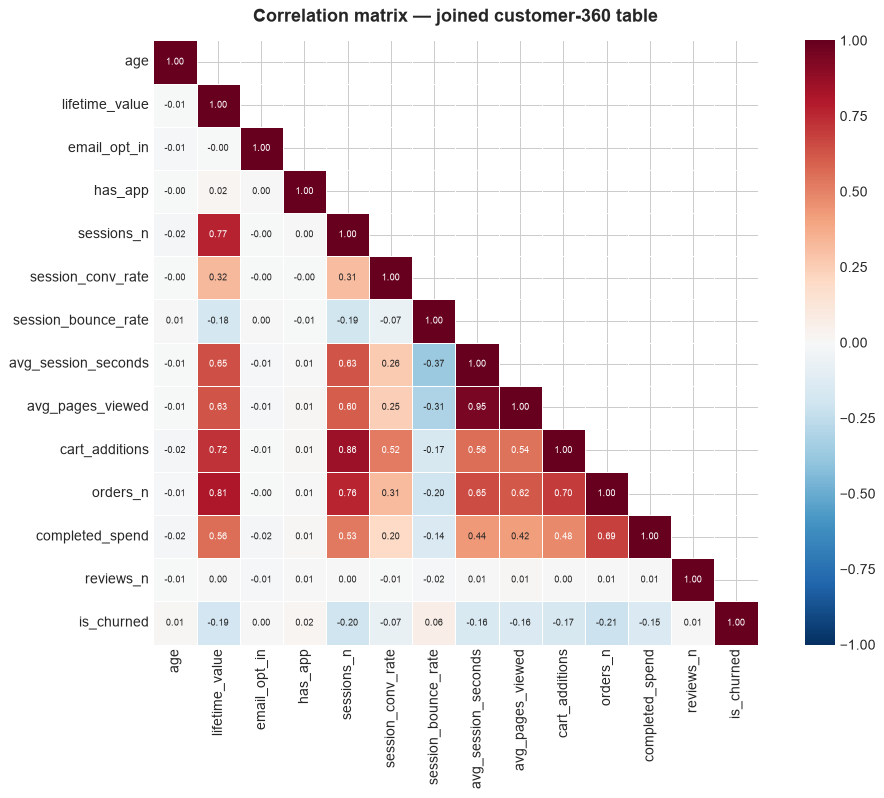

Strongest correlations with is_churned:
  orders_n                -0.213   (from the join)
  sessions_n              -0.198   (from the join)
  lifetime_value          -0.187   (customers.csv)
  cart_additions          -0.170   (from the join)
  avg_session_seconds     -0.164   (from the join)
  avg_pages_viewed        -0.156   (from the join)
  completed_spend         -0.152   (from the join)
  session_conv_rate       -0.070   (from the join)


In [19]:
# Correlations, on the joined table rather than customers.csv alone —
# a single-table heatmap here would be five columns of very little.
CORR_COLS = [
    "age",
    "lifetime_value",
    "email_opt_in",
    "has_app",
    "sessions_n",
    "session_conv_rate",
    "session_bounce_rate",
    "avg_session_seconds",
    "avg_pages_viewed",
    "cart_additions",
    "orders_n",
    "completed_spend",
    "reviews_n",
    "is_churned",
]
corr = c360[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr), k=1)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    mask=mask,
    annot_kws={"size": 7},
    vmin=-1,
    vmax=1,
)
ax.set_title(
    "Correlation matrix — joined customer-360 table",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

print("Strongest correlations with is_churned:")
target_corr = (
    corr["is_churned"].drop("is_churned").sort_values(key=abs, ascending=False)
)
for name, value in target_corr.head(8).items():
    origin = "customers.csv" if name in SINGLE_TABLE else "from the join"
    print(f"  {name:<22} {value:>+7.3f}   ({origin})")

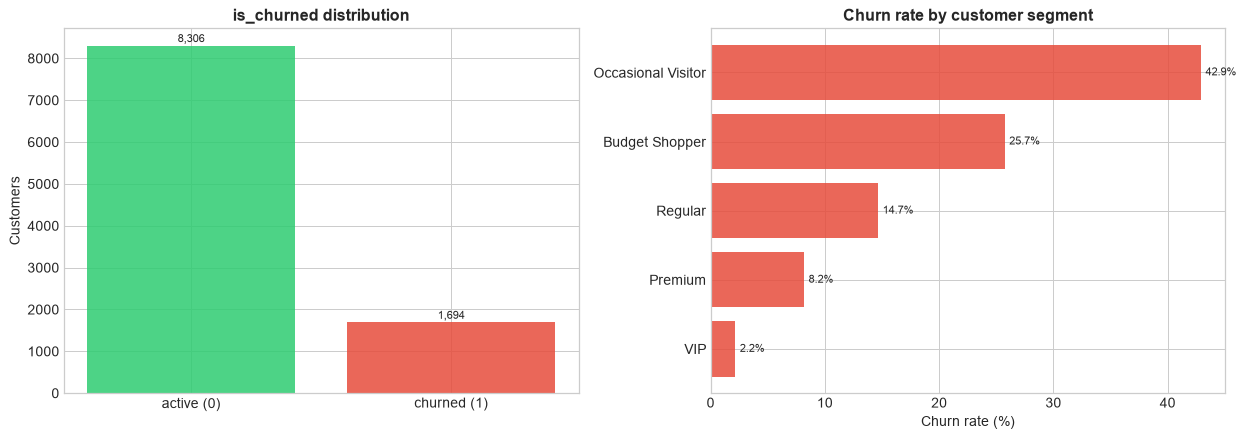

Overall churn rate: 16.94%
Segment spread: 2.16% (VIP) to 42.91% (Occasional Visitor)


In [20]:
target_col = "is_churned"
counts = df[target_col].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bars = ax1.bar(
    ["active (0)", "churned (1)"],
    counts.values,
    color=["#2ecc71", "#e74c3c"],
    alpha=0.85,
)
ax1.set_title(f"{target_col} distribution", fontweight="bold")
ax1.set_ylabel("Customers")
for bar, value in zip(bars, counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        fontsize=9,
    )

by_seg = df.groupby("segment")[target_col].mean().sort_values()
bars = ax2.barh(by_seg.index, by_seg.values * 100, color="#e74c3c", alpha=0.85)
ax2.set_xlabel("Churn rate (%)")
ax2.set_title("Churn rate by customer segment", fontweight="bold")
for bar, value in zip(bars, by_seg.values * 100):
    ax2.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {df[target_col].mean():.2%}")
print(
    f"Segment spread: {by_seg.min():.2%} ({by_seg.index[0]}) to "
    f"{by_seg.max():.2%} ({by_seg.index[-1]})"
)

## 8. Evaluation Readiness <a id='evaluation'></a>

What to carry into a modelling notebook, including the two leakage traps this dataset
contains.

In [21]:
print("Evaluation readiness checklist")
print("-" * 62)
print(f"Target                   : {TARGET_COL} ({churn_rate:.2%} positive)")
print(f"Task                     : {MODELING_TASK}")
print(f"Metric                   : {PRIMARY_METRIC}")
print(
    f"Validation               : StratifiedKFold(5, shuffle=True, random_state={SEED})"
)
print(
    f"Baseline to beat         : ROC-AUC {single_scores.mean():.4f} "
    f"(customers.csv only)"
)
print(f"Joined reference         : ROC-AUC {joined_scores.mean():.4f}")
print()
print("Leakage traps in this dataset:")
print("  1. transactions.unit_price is exactly products.price x (1 - discount/100).")
print("     Never use it as a feature when the target is price or discount.")
print("  2. customers.lifetime_value is assigned from segment, so it encodes the")
print("     same generator that set the churn probability. It is legitimate as a")
print("     feature, but it is not an independent measurement of spend.")
print()
print("Aggregation hygiene:")
print("  - Build session/transaction aggregates inside each CV fold if you add")
print("    time-windowed features; the aggregates here use the full history and")
print("    are safe only because the label is not time-indexed.")
print("  - Left joins leave NaN for customers with no events. Zero-fill counts,")
print("    but keep rates (conversion, bounce) as NaN and impute deliberately.")

Evaluation readiness checklist
--------------------------------------------------------------
Target                   : is_churned (16.94% positive)
Task                     : classification
Metric                   : ROC-AUC (5-fold stratified)
Validation               : StratifiedKFold(5, shuffle=True, random_state=42)
Baseline to beat         : ROC-AUC 0.6605 (customers.csv only)
Joined reference         : ROC-AUC 0.6789

Leakage traps in this dataset:
  1. transactions.unit_price is exactly products.price x (1 - discount/100).
     Never use it as a feature when the target is price or discount.
  2. customers.lifetime_value is assigned from segment, so it encodes the
     same generator that set the churn probability. It is legitimate as a
     feature, but it is not an independent measurement of spend.

Aggregation hygiene:
  - Build session/transaction aggregates inside each CV fold if you add
    time-windowed features; the aggregates here use the full history and
    are safe 

## 9. Key Takeaways <a id='takeaways'></a>

- **The five tables join without preprocessing.** Every `customer_id` and
  `product_id` in the child tables resolves to a parent row, and the price chain
  between `transactions` and `products` is exact. Section 3 checks this rather than
  taking the description's word for it.
- **The join carries real signal.** Behavioural aggregates lift 5-fold churn ROC-AUC
  from 0.660 to 0.679 and win every fold. Modest, but consistent — and in the
  coefficient plot the two largest joined weights, order count and session count,
  are both larger than everything from `customers.csv` except `lifetime_value`.
- **Revenue is concentrated, refunds are not.** Electronics alone is 27.6% of
  completed revenue, while refund rates across all 15 categories fit inside a
  two-point band (13.4%-15.4%). Category is a good revenue feature and a poor
  refund feature.
- **`lifetime_value` is a segment proxy, not a ledger.** It correlates with realized
  completed spend at r = 0.56. Build your own spend target from `transactions` if you
  need one.
- **`review_text` draws from 15 template sentences.** Enough to wire up a sentiment
  pipeline end to end, not enough to benchmark one.

### Where to go next

- RFM segmentation from `transactions` recency / frequency / monetary value, then
  compare the clusters against the built-in `segment` column.
- Market basket analysis on transactions grouped by customer and day.
- Session-level conversion modelling on `sessions.converted`, joined to customer
  attributes — a different grain from the customer-level model here.
- Time-windowed features (last-30-day sessions, spend trend) built per fold, which is
  where the join starts to pay off more than the 0.02 AUC measured above.

*The data is synthetic and generated by a seeded script. It is built for teaching,
benchmarking and prototyping, not for drawing conclusions about real shoppers.*

### Interpreting the lift, and where it stops

The join helps **because** the behavioural tables measure engagement that
`customers.csv` only proxies: session count and order count are direct counts of
what a customer did, while `lifetime_value` is a segment label assigned at
generation time. That is also why the improvement is modest rather than dramatic —
churn here is largely determined at generation, **therefore** no feature set
recovers signal that was never written into the data.

### Limitations and caveats

- **This data is synthetic.** It is generated by `create_dataset.py` with a fixed
  seed. Relationships hold exactly because they were authored, so results here
  validate a *pipeline*, not a real-world hypothesis about e-commerce.
- **Two leakage traps.** The price chain is exact
  (`unit_price == price * (1 - discount_applied/100)` for 100.00% of rows), so any
  model targeting price or discount will score perfectly and mean nothing.
  `lifetime_value` is segment-assigned rather than summed from transactions
  (r = 0.556 against realized spend) — a caveat worth carrying into any model that
  treats it as a behavioural measure.
- **Reverse coverage is not complete.** Every child row resolves to a parent, but
  not every customer appears in every child table (99.4% / 98.2% / 91.7%). Aggregates
  therefore need an explicit fill policy; the zero-fill used here is a trade-off that
  treats "no reviews" as "no signal", which is not the same thing.
- **One target, one split.** The 0.660 -> 0.679 result is a single 5-fold comparison
  on one target with one seed. It is enough to show the join carries signal, not
  enough to rank feature sets.
